<a href="https://colab.research.google.com/github/mokshManchandani/data-science/blob/deeplearning-pytorch-udemy/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ANN For regression

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


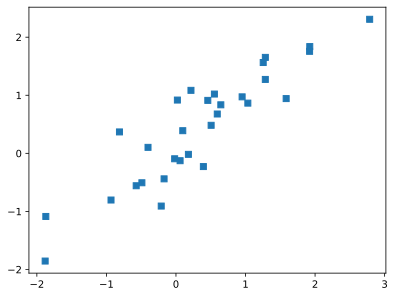

In [ ]:
# Create Data
N = 30
x = torch.randn(N,1)
y = x + torch.randn(N,1) / 2


plt.plot(x,y,'s');

In [ ]:
# build model
ANNReg = nn.Sequential(
  nn.Linear(1, 1),
  nn.ReLU(),
  nn.Linear(1,1)
)

ANNReg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
# learning rate
learning_rate = 0.05

# loss function

lossfunc = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(ANNReg.parameters(), lr=learning_rate)

In [ ]:
# training loop
numepochs = 500
lossi = torch.zeros(numepochs)

for epochi in range(numepochs):
  yHat = ANNReg(x)
  loss = lossfunc(yHat, y)
  lossi[epochi] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


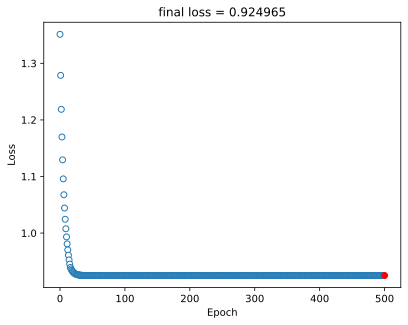

In [ ]:
predictions = ANNReg(x)
testloss = (predictions - y).pow(2).mean()

plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
plt.plot(numepochs, testloss.detach().numpy(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('final loss = %g'%testloss.item())
plt.show();

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


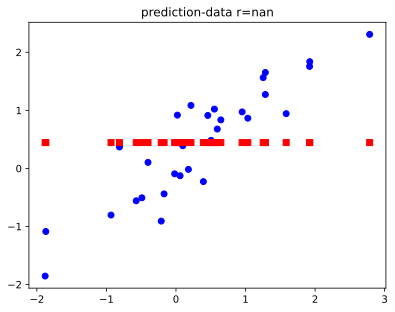

In [ ]:
plt.plot(x, y, 'bo', label='real data')
plt.plot(x, predictions.detach(), 'rs', label='predictions')
plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

Code challenge for the above.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-19-2da2361c6caa>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
def create_data(N, m=1):
  x = torch.randn(N,1)
  y = m * x + torch.randn(N,1) / 2
  # plt.plot(x,y,'s');
  return x, y

In [ ]:
def build_and_train_model(x, y, num_epochs, learning_rate, loss_func, optimizer_func):
# package the code of building and training the model into a function
  # build the model
  model = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU(),
    nn.Linear(1,1)
  )


  # init the optimizer
  optimizer = optimizer_func(model.parameters(), lr=learning_rate)
  # track the stats
  lossi = torch.zeros(num_epochs)


  # train the model
  for epochi in range(num_epochs):
    yHat = model(x)
    loss = loss_func(yHat, y)
    lossi[epochi]= loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  predictions = model(x)
  # testloss = (predictions - y).pow(2).mean()

  # plt.figure(figsize=(10,4))
  # # show two plots on the same row
  # # show the loss over epochs
  # plt.subplot(1,2,1)
  # plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
  # plt.xlabel('Epoch')
  # plt.ylabel('Loss')
  # plt.title('final loss = %g'%testloss.item())

  # # show the accuracy
  # plt.subplot(1,2,2)
  # plt.plot(x, y, 'bo', label='real data')
  # plt.plot(x, predictions.detach(), 'rs', label='predictions')
  # plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

  return lossi, predictions


In [ ]:
# get the data
x, y = create_data(N = 50)

In [ ]:
# train the model
lossi, predictions = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)

In [ ]:
# create slopes from -2, +2 in 21 steps

slopes = torch.linspace(-2,2,21)
num_experiments = 50

results = np.zeros((len(slopes), num_experiments, 2))


for slopeidx, slope in enumerate(slopes):
  for experimenti in range(num_experiments):
    x, y = create_data(N = 50, m = slope)
    lossi, yHat = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)
    results[slopeidx, experimenti, 0] = lossi[-1].item()
    results[slopeidx, experimenti, 1] = np.corrcoef(y.T, yHat.detach().T)[0,1]

results.shape


/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


(21, 50, 2)

In [ ]:
# reset nan-> 0
results[np.isnan(results)] = 0

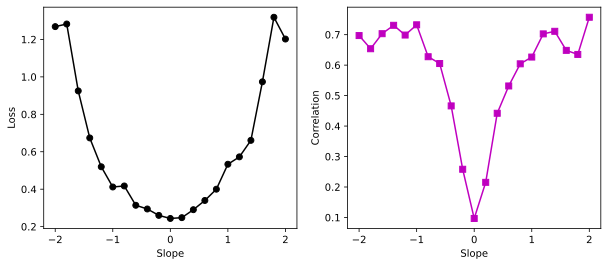

In [ ]:
fix, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(slopes, results[:,:,0].mean(axis=1), 'ko-')
ax[0].set_xlabel('Slope')
ax[0].set_ylabel('Loss')

ax[1].plot(slopes, results[:,:,1].mean(axis=1), 'ms-')
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Correlation')

plt.show()

## ANN For classification - binary classification

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-17-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


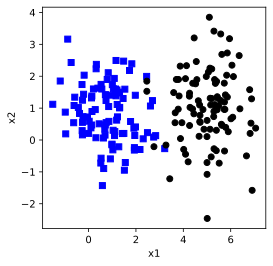

In [ ]:
nPerCluster = 100
blur = 1
A = [1, 1]
B = [5, 1]

a = [ A[0] + np.random.randn(nPerCluster) * blur, A[1] + np.random.randn(nPerCluster) * blur]
b =  [ B[0] + np.random.randn(nPerCluster) * blur, B[1] + np.random.randn(nPerCluster) * blur]


# true labels
labels = np.vstack((np.zeros((nPerCluster,1)), np.ones((nPerCluster,1))))

data_points = np.hstack((a,b)).T

data = torch.tensor(data_points).float()
labels = torch.tensor(labels).float()

fig = plt.figure(figsize=(4,4))

plt.plot(data[np.where(labels == 0)[0],0], data[np.where(labels == 0)[0], 1],'bs')
plt.plot(data[np.where(labels == 1)[0],0], data[np.where(labels == 1)[0], 1],'ko')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

In [ ]:
ANNClassify = nn.Sequential(
  nn.Linear(2, 1),
  nn.ReLU(),
  nn.Linear(1, 1),
  nn.Sigmoid()
)
ANNClassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

In [ ]:
learning_rate = .01
lossf = nn.BCELoss()
optimizer = torch.optim.SGD(ANNClassify.parameters(), lr=learning_rate)

In [ ]:
numepochs = 1000
lossi = torch.zeros(numepochs)

for epochi in range(numepochs):
  yHat = ANNClassify(data)
  loss = lossf(yHat, labels)
  lossi[epochi] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

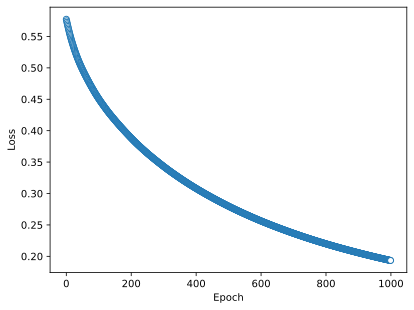

In [ ]:
plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show();

In [ ]:
predictions = ANNClassify(data)
predlabels = predictions > .5



misclassified = np.where(predlabels != labels)[0]
print(np.where(predlabels != labels))

totalacc = 100 - 100 * len(misclassified) / len(labels)
print(f'total accuracy = {totalacc}%')

(array([15, 51, 62, 74, 86, 92, 96]), array([0, 0, 0, 0, 0, 0, 0]))
total accuracy = 96.5%


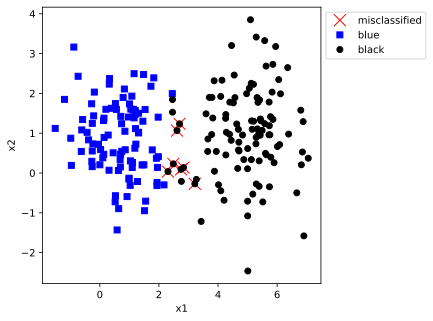

In [ ]:
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified, 0], data[misclassified, 1], 'rx', markersize=12)
plt.plot(data[np.where(~predlabels)[0], 0], data[np.where(~predlabels)[0], 1], 'bs')
plt.plot(data[np.where(predlabels)[0], 0], data[np.where(predlabels)[0], 1], 'ko')
plt.legend(['misclassified', 'blue', 'black'], bbox_to_anchor=(1,1))
plt.xlabel('x1')
plt.ylabel('x2');

The appropriate learning rate experiment

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
# create the data
n_per_cluster = 100
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]

a = [ A[0]+np.random.randn(n_per_cluster)*blur, A[1]+np.random.randn(n_per_cluster)*blur ]
b = [ B[0]+np.random.randn(n_per_cluster)*blur, B[1]+np.random.randn(n_per_cluster)*blur ]

# class 0, class 1.
# class 0 -> blue
# class 1 -> black
labels = np.vstack((np.zeros((n_per_cluster,1)), np.ones((n_per_cluster,1))))

# create the x1x2 coordinates for the labels above.
data_points = np.hstack((a, b)).T

# convert to torch tensors
data = torch.from_numpy(data_points).float()
labels = torch.from_numpy(labels).float()

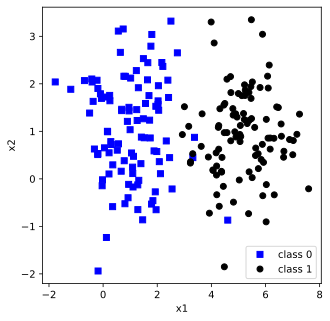

In [ ]:
# display the data landscape
fig = plt.figure(figsize=(5, 5))
plt.plot(data[np.where(labels == 0)[0],0], data[np.where(labels==0)[0], 1], 'bs',label="class 0")
plt.plot(data[np.where(labels == 1)[0],0], data[np.where(labels==1)[0], 1], 'ko', label="class 1")
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [ ]:
def createANNModel(learning_rate):
  model = nn.Sequential(
    nn.Linear(2, 1),
    nn.ReLU(),
    nn.Linear(1, 1)
  )

  loss_func = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  return model, loss_func, optimizer

In [ ]:
def train_model(x, y, model, loss_func, optimizer, num_epochs):
  losses = torch.zeros(num_epochs)

  # train and track
  for epoch in range(num_epochs):
    yhat = model(x)
    loss = loss_func(yhat, y)
    losses[epoch] = loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # final predictions after training the model
  predictions = model(x)

  # accuracy of the model
  totalacc = 100 * torch.mean(((predictions > 0) == y).float())
  return losses, predictions, totalacc



In [ ]:
model, loss_func, optimizer = createANNModel(learning_rate=0.01)

In [ ]:
losses, predictions, totalacc = train_model(data, labels, model, loss_func, optimizer, 2000)

final accuracy: 98.00


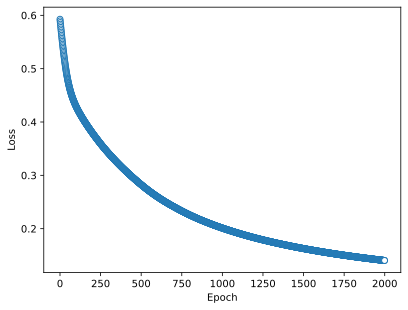

In [ ]:
print(f"final accuracy: {totalacc:.2f}")
plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
num_epochs = 1000
learning_rates = np.linspace(.001, .1, 40)
accByLr = []
allLosses = np.zeros((len(learning_rates), num_epochs))

for i, lr in enumerate(learning_rates):
  model, loss_func, optimizer = createANNModel(learning_rate = lr)
  losses, predictions, totalacc = train_model(
    x = data,
    y = labels,
    model = model,
    loss_func = loss_func,
    optimizer = optimizer,
    num_epochs = num_epochs
  )
  accByLr.append(totalacc.item())
  allLosses[i, :] = losses.detach().numpy()

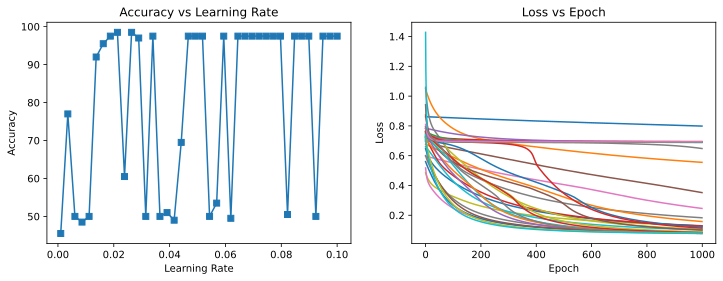

In [ ]:
# plot the results
fig, ax = plt.subplots(1,2,figsize=(12, 4))

ax[0].plot(learning_rates, accByLr, 's-')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Accuracy')
# ax[0].set_xscale('log')
ax[0].set_title('Accuracy vs Learning Rate')

ax[1].plot(allLosses.T)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Loss vs Epoch')

plt.show()

In [ ]:
# to take into account the variablity due to randomness we need to run the same experiment for n number of times

num_experiments = 50
results = np.zeros((num_experiments, len(learning_rates)))
num_epochs = 500

for expi in range(num_experiments):
  for i, lr in enumerate(learning_rates):
    model, loss_func, optimizer = createANNModel(learning_rate = lr)
    losses, predictions, totalacc = train_model(
      x = data,
      y = labels,
      model = model,
      loss_func = loss_func,
      optimizer = optimizer,
      num_epochs = num_epochs
    )
    results[expi, i] = totalacc.item()


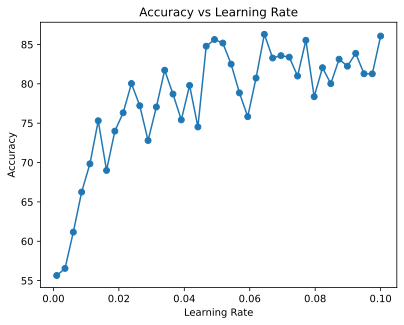

In [ ]:
plt.plot(learning_rates, results.mean(axis=0), 'o-')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Learning Rate')
plt.show()

## Multilayer ANN

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display

In [ ]:
display.set_matplotlib_formats('svg')

<ipython-input-2-4181f5e13c96>:1: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


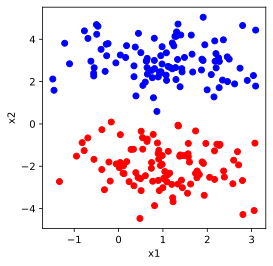

In [ ]:
# create the data
num_per_cluster = 100
blur = 1

A = [ 1, 3  ]
B = [ 1, -2 ]

a = [
  A[0] + np.random.randn(num_per_cluster) * blur,
  A[1] + np.random.randn(num_per_cluster) * blur
]

b = [
  B[0] + np.random.randn(num_per_cluster) * blur,
  B[1] + np.random.randn(num_per_cluster) * blur
]


labels = np.vstack(
  (
      np.zeros((num_per_cluster, 1)),
      np.ones((num_per_cluster, 1))
  )
)

data = np.hstack((a, b)).T

data = torch.from_numpy(data).float()
labels = torch.from_numpy(labels).float()

_ = plt.figure(figsize=(4,4))
plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], 'bo', label='class 0')
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 1)[0], 1], 'ro', label='class 1')
plt.xlabel('x1')
plt.ylabel('x2');

In [ ]:
def create_model(learning_rate):
  model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.ReLU(),
    nn.Linear(1, 1),
    nn.Sigmoid()
  )

  loss_func = nn.BCELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
  return model, loss_func, optimizer

In [ ]:
def train_model(x, y, model, loss_func, optimizer, num_epochs):
  losses = torch.zeros(num_epochs)
  for epoch in range(num_epochs):
    yhat = model(x)
    loss = loss_func(yhat, y)
    losses[epoch] = loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  predictions = model(x)
  totalacc = 100 * torch.mean(((predictions > .5) == y).float())
  return losses, totalacc

In [ ]:
model, loss_func, optimizer = create_model(learning_rate = .8)
losses, totalacc = train_model(data, labels, model, loss_func, optimizer, num_epochs=500)
totalacc

tensor(100.)

In [ ]:
learning_rates = np.linspace(.001, .1, 50)
num_epochs = 500
accByLr = []
allLosses = np.zeros((len(learning_rates), num_epochs))

for i, lr in enumerate(learning_rates):
  model, loss_func, optimizer = create_model(learning_rate = lr)
  losses, totalacc = train_model(data, labels, model, loss_func, optimizer, num_epochs)
  allLosses[i, :] = losses.detach().numpy()
  accByLr.append(totalacc.item())

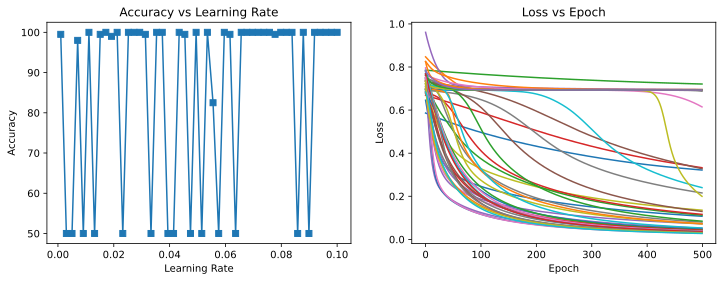

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(learning_rates, accByLr, 's-')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy vs Learning Rate')

ax[1].plot(allLosses.T)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Loss vs Epoch')

plt.show()

In [ ]:
sum(torch.tensor(accByLr)>70)/len(accByLr)

tensor(0.7200)

## Multilayer linear model

In [ ]:
def create_model_linear(learning_rate):
  model = nn.Sequential(
    nn.Linear(2, 16),
    nn.Linear(16, 1),
    nn.Linear(1,1),
    nn.Sigmoid()
  )

  loss_func = nn.BCELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
  return model, loss_func, optimizer


In [ ]:
model, loss_func, optimizer = create_model_linear(learning_rate = .8)
losses, totalacc = train_model(data, labels, model, loss_func, optimizer, num_epochs=500)
totalacc

tensor(100.)

In [ ]:
accByLr = []
allLosses = np.zeros((len(learning_rates), num_epochs))


for i, lr in enumerate(learning_rates):
  model, loss_func, optimizer = create_model_linear(learning_rate = lr)
  losses, totalacc = train_model(data, labels, model, loss_func, optimizer, num_epochs)
  allLosses[i, :] = losses.detach().numpy()
  accByLr.append(totalacc.item())

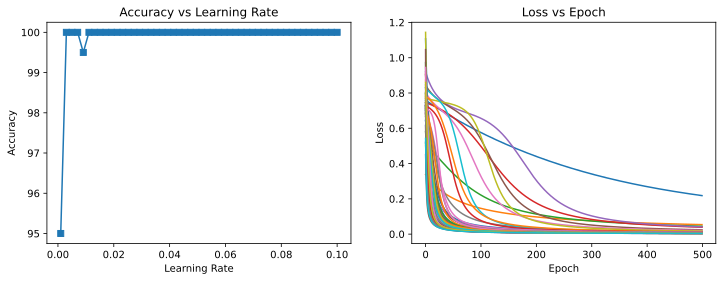

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
ax[0].plot(learning_rates, accByLr, 's-')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy vs Learning Rate')

ax[1].plot(allLosses.T)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Loss vs Epoch')

plt.show()

In [ ]:
sum(torch.tensor(accByLr) > 70) / len(accByLr)

tensor(1.)

##Multiclass Classification

In [ ]:
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-ad12617af1bf>:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
# load the data
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


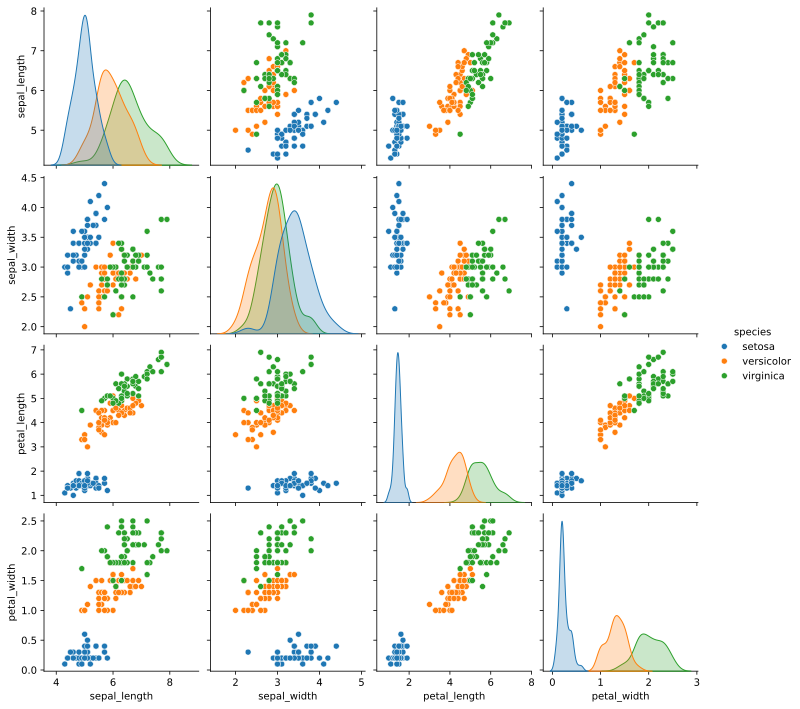

In [ ]:
sns.pairplot(iris, hue='species')
plt.show()

In [ ]:
# convert the data to tensors
data = torch.tensor(iris.drop('species', axis=1).values).float()

# create the labels
# class 0 -> setosa
# class 1 -> versicolor
# class 2 -> virginica
labels = torch.zeros(len(data), dtype=torch.long)

labels[iris['species'] == 'versicolor'] = 1
labels[iris['species'] == 'virginica'] = 2

labels.shape, data.shape

(torch.Size([150]), torch.Size([150, 4]))

In [ ]:
# create model to classifiy between the three classes
model = nn.Sequential(
  nn.Linear(4, 64),
  nn.ReLU(),
  nn.Linear(64,64),
  nn.ReLU(),
  nn.Linear(64,3),
)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .01)
soft_max = nn.Softmax(dim = 1)


In [ ]:
numepochs = 1000

losses = torch.zeros(numepochs)
runningAcc = []

for epochi in range(numepochs):
  yHat = model(data)
  loss = loss_func(yHat, labels)
  losses[epochi] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  with torch.no_grad():
    matches = torch.argmax(yHat, dim=1) == labels
    matches = matches.float().mean()
    acc = 100 * matches
    runningAcc.append(acc)


In [ ]:
# the largest value in logits will be the higest p value after softmax hence we dont need this explicit step for accuracy.
# assert torch.all(torch.argmax(yHat, dim = 1) == torch.argmax(soft_max(yHat), dim = 1))

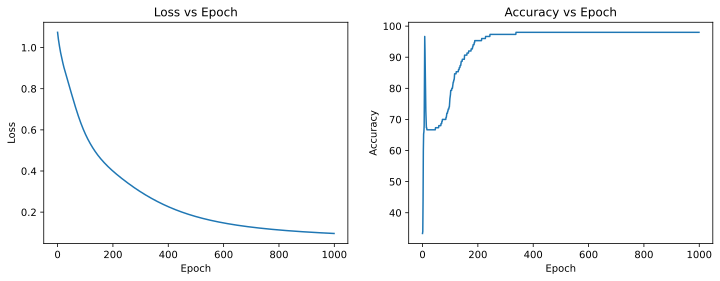

In [ ]:
# plot acc and loss plots
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_title('Loss vs Epoch')

ax[1].plot(runningAcc)
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_title('Accuracy vs Epoch')

plt.show()

In [ ]:
# class based accuracy
predictions = torch.argmax(model(data), dim=1)
num_classes = len(torch.unique(labels))
class_accuracies = {}
for class_label in range(num_classes):
  class_indices = torch.where(labels == class_label)[0]
  class_predictions = predictions[class_indices]
  class_correct = (class_predictions == class_label).sum().item()
  class_total = len(class_indices)
  class_accuracy = (class_correct / class_total) * 100
  class_accuracies[f"Class {class_label}"] = f"{class_accuracy:.2f}%"

overall_accuracy = (torch.sum(predictions == labels).item() / len(labels)) * 100
class_accuracies["Overall Accuracy"] = f"{overall_accuracy:.2f}%"

for class_label, accuracy in class_accuracies.items():
  print(f"{class_label}: {accuracy}")

Class 0: 100.00%
Class 1: 94.00%
Class 2: 100.00%
Overall Accuracy: 98.00%


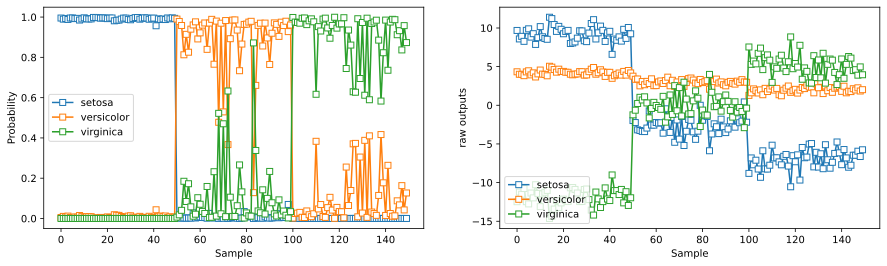

In [ ]:
# how well does the model differentiate (assign probabilites for each sample in the data set)
predictions = model(data)
fig = plt.figure(figsize=(15, 4))
plt.subplot(1,2,1)
plt.plot(soft_max(predictions).detach().numpy(), 's-', markerfacecolor='w')
plt.xlabel('Sample')
plt.ylabel('Probability')
plt.legend(iris['species'].unique())

plt.subplot(1,2,2)
plt.plot(predictions.detach().numpy(), 's-', markerfacecolor='w')
plt.xlabel('Sample')
plt.ylabel('raw outputs')
plt.legend(iris['species'].unique(),loc='lower left')


plt.show()

Code challenge for the above : qwerties in multiclass setup

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


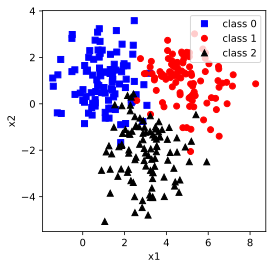

In [ ]:
# create the data

num_per_cluster = 100
blur = 1

# centroid for class 0
A = [ 1, 1 ]
# centroid for class 1
B = [ 5, 1 ]
# centroid for class 2
C = [ 3, -2 ]


a = [
  A[0] + np.random.randn(num_per_cluster) * blur,
  A[1] + np.random.randn(num_per_cluster) * blur
]

b = [
  B[0] + np.random.randn(num_per_cluster) * blur,
  B[1] + np.random.randn(num_per_cluster) * blur
]

c = [
  C[0] + np.random.randn(num_per_cluster) * blur,
  C[1] + np.random.randn(num_per_cluster) * blur
]

Y = np.vstack(
  (
      np.zeros((num_per_cluster, 1)),
      np.ones((num_per_cluster, 1)),
      1+np.ones((num_per_cluster, 1)),
  )
)


X = np.hstack((a, b, c)).T

X = torch.from_numpy(X).float()
Y = torch.from_numpy(Y).long().squeeze()

_ = plt.figure(figsize=(4,4))
plt.plot(X[np.where(Y == 0)[0], 0], X[np.where(Y == 0)[0], 1], 'bs', label='class 0')
plt.plot(X[np.where(Y == 1)[0], 0], X[np.where(Y == 1)[0], 1], 'ro', label='class 1')
plt.plot(X[np.where(Y == 2)[0], 0], X[np.where(Y == 2)[0], 1], 'k^', label='class 2')
plt.xlabel('x1')
plt.ylabel('x2');
plt.legend(loc='upper right');

In [ ]:
# create the same architecture
model = nn.Sequential(
  nn.Linear(2, 64),
  nn.ReLU(),
  nn.Linear(64,64),
  nn.ReLU(),
  nn.Linear(64,3),
  nn.Softmax(dim = 1)
)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .01)
sm = nn.Softmax(dim = 1)

In [ ]:
preds = model(X)
preds.shape

torch.Size([300, 3])

In [ ]:
num_epochs = 10_000
losses = torch.zeros(num_epochs)
runningAcc = []

for epochi in range(num_epochs):
  yHat = model(X)
  loss = loss_func(yHat, Y)
  losses[epochi] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  with torch.no_grad():
    matches = torch.argmax(yHat, dim = 1) == Y
    matches = matches.float().mean()
    acc = 100 * matches
    runningAcc.append(acc)


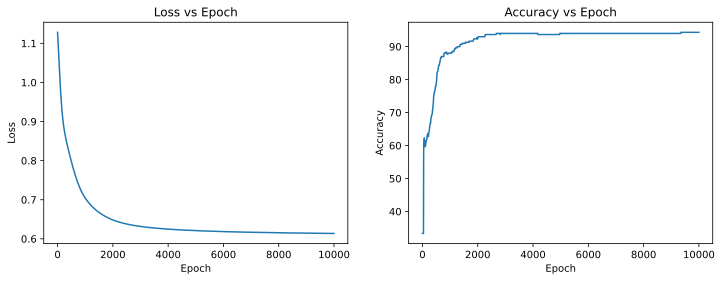

In [ ]:
# plot acc and loss plots
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_title('Loss vs Epoch')

ax[1].plot(runningAcc)
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_title('Accuracy vs Epoch')

plt.show()

In [ ]:
# class based accuracy
predictions = torch.argmax(model(X), dim=1)
num_classes = len(torch.unique(Y))
class_accuracies = {}
for class_label in range(num_classes):
  class_indices = torch.where(Y == class_label)[0]
  class_predictions = predictions[class_indices]
  class_correct = (class_predictions == class_label).sum().item()
  class_total = len(class_indices)
  class_accuracy = (class_correct / class_total) * 100
  class_accuracies[f"Class {class_label}"] = f"{class_accuracy:.2f}%"

overall_accuracy = (torch.sum(predictions == Y).item() / len(Y)) * 100 # changed sequeeze to squeeze
class_accuracies["Overall Accuracy"] = f"{overall_accuracy:.2f}%"

for class_label, accuracy in class_accuracies.items():
  print(f"{class_label}: {accuracy}")

Class 0: 93.00%
Class 1: 97.00%
Class 2: 93.00%
Overall Accuracy: 94.33%


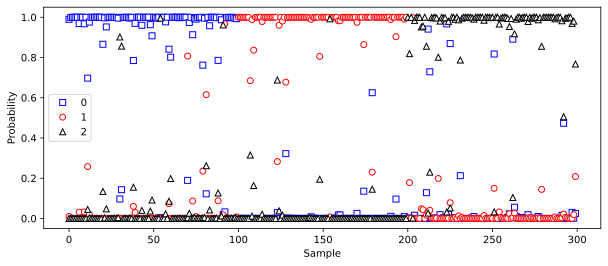

In [ ]:
fig = plt.figure(figsize=(10,4))
colorshape = ['bs', 'ro', 'k^']
for i in range(3):
  plt.plot(predictions[:,i].detach().numpy(), colorshape[i], markerfacecolor='w')
plt.xlabel('Sample')
plt.ylabel('Probability')
plt.legend(Y.unique().numpy())
plt.show()

## Number of hidden units experiment on iris


In [1]:
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-ad12617af1bf>:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
# load the iris data
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


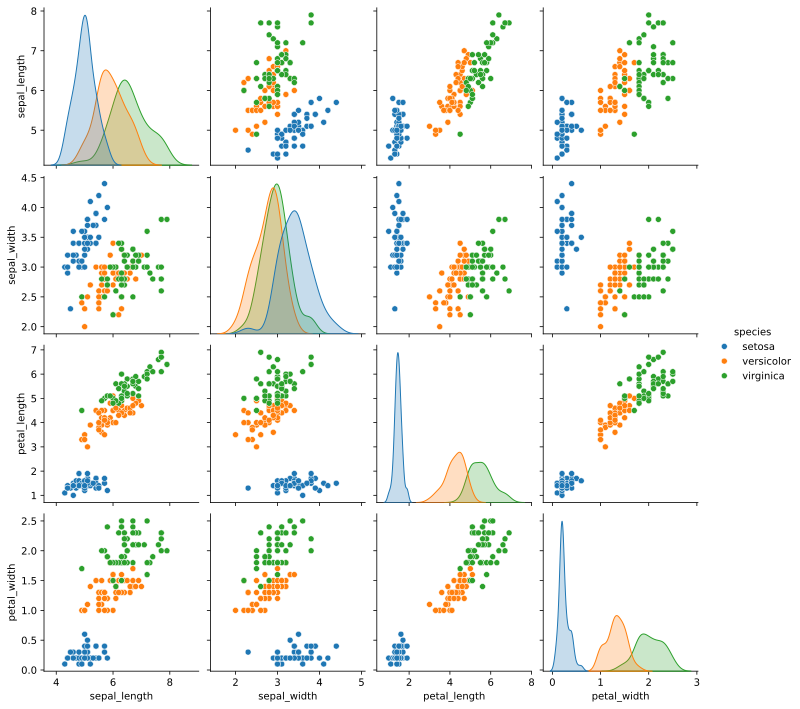

In [3]:
sns.pairplot(iris, hue='species')
plt.show()

In [4]:
# create the data set
X = torch.tensor(iris.drop('species', axis=1).values).float()
Y = torch.zeros(len(X), dtype=torch.long)
Y[iris['species'] == 'versicolor'] = 1
Y[iris['species'] == 'virginica'] = 2

X.shape, Y.shape

(torch.Size([150, 4]), torch.Size([150]))

In [12]:
def createIrisModel(num_hidden_units, learning_rate=None):
  model = nn.Sequential(
    nn.Linear(4, num_hidden_units),
    nn.ReLU(),
    nn.Linear(num_hidden_units,num_hidden_units),
    nn.ReLU(),
    nn.Linear(num_hidden_units, 3)
  )
  lr = 0.01 if not learning_rate else learning_rate
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr = lr)
  return model, loss_func, optimizer

In [6]:
def trainModel(X, Y, model, loss_func, optimizer, numepochs=None):
  numepochs = 150 if not numepochs else numepochs
  for epochi in range(numepochs):
    yHat = model(X)
    loss = loss_func(yHat, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  predictions = torch.argmax(model(X), dim = 1)
  predictions = (predictions == Y).float()
  return 100 * predictions.mean()



In [7]:
upper_n_hidden = 129

numhiddenunits = np.arange(1, upper_n_hidden)
accuracies = torch.zeros(len(numhiddenunits))

for hiddeni, num_hidden_unit in enumerate(numhiddenunits):
  model, loss_func, optimizer = createIrisModel(num_hidden_unit)
  accuracies[hiddeni] = trainModel(X, Y, model, loss_func, optimizer)



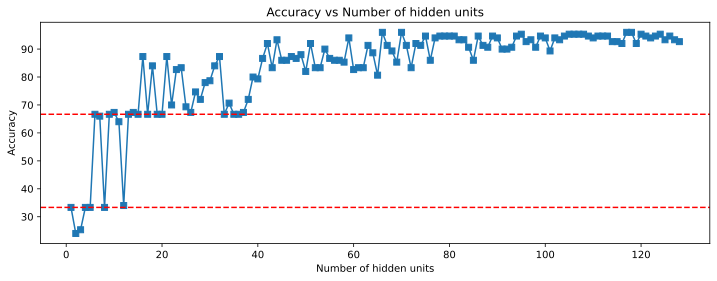

In [8]:
# plot accuracy vs num_hidden_units
fig, ax = plt.subplots(1,1, figsize=(12, 4))

ax.plot(numhiddenunits, accuracies.detach().numpy(), 's-')
# plot 1/3rd and 2/3rd lines
ax.axhline(100/3, color='r', linestyle='--')
ax.axhline(200/3, color='r', linestyle='--')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Number of hidden units')
ax.set_title('Accuracy vs Number of hidden units')

plt.show()

In [10]:
# experiment for all the hidden units but longer train times
# fixed epochs now are 1000

upper_n_hidden = 129
numepochs = 1000
numhiddenunits = np.arange(1, upper_n_hidden)
accuracies = torch.zeros(len(numhiddenunits))

for hiddeni, num_hidden_unit in enumerate(numhiddenunits):
  model, loss_func, optimizer = createIrisModel(num_hidden_unit)
  accuracies[hiddeni] = trainModel(X, Y, model, loss_func, optimizer, numepochs)


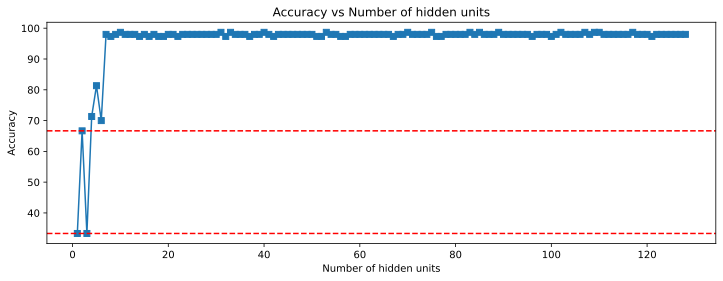

In [11]:
fig, ax = plt.subplots(1,1, figsize=(12, 4))
ax.plot(numhiddenunits, accuracies.detach().numpy(), 's-')
ax.axhline(100/3, color='r', linestyle='--')
ax.axhline(200/3, color='r', linestyle='--')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Number of hidden units')
ax.set_title('Accuracy vs Number of hidden units')
plt.show()

In [13]:
# effect of number of hidden units accuracy and learning rate keeping epochs = 150
learning_rates = [0.001, 0.01, 0.1]
num_hidden_units = np.arange(1, 129)
accuracies = torch.zeros(len(learning_rates), len(num_hidden_units))

for i, lr in enumerate(learning_rates):
  for j, num_hidden_unit in enumerate(num_hidden_units):
    model, loss_func, optimizer = createIrisModel(num_hidden_unit, learning_rate=lr)
    accuracies[i, j] = trainModel(X, Y, model, loss_func, optimizer)



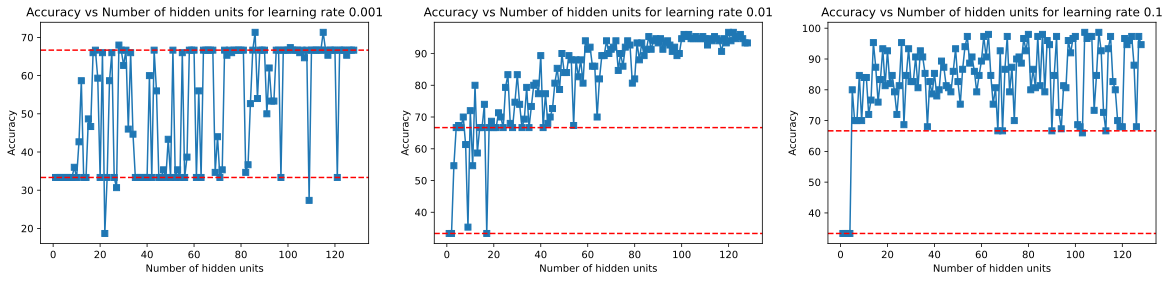

In [16]:
# plot the accuracies as the function of hidden units and learning rates
# display all the plots as different subplots
fig, ax = plt.subplots(1,3, figsize=(20, 4))
for i, lr in enumerate(learning_rates):
  ax[i].plot(num_hidden_units, accuracies[i, :].detach().numpy(), 's-')
  ax[i].axhline(100/3, color='r', linestyle='--')
  ax[i].axhline(200/3, color='r', linestyle='--')
  ax[i].set_ylabel('Accuracy')
  ax[i].set_xlabel('Number of hidden units')
  ax[i].set_title(f'Accuracy vs Number of hidden units for learning rate {lr}')

plt.show()

## Counting with the number of trainable parameters in nn model

In [2]:
import torch
import torch.nn as nn

In [3]:
widenet = nn.Sequential(
  nn.Linear(2,4),
  nn.Linear(4,3)
)

deepnet = nn.Sequential(
  nn.Linear(2,2),
  nn.Linear(2,2),
  nn.Linear(2,3)
)

In [4]:
for p in widenet.named_parameters():
  print(p)
  print()

('0.weight', Parameter containing:
tensor([[ 0.1906, -0.6304],
        [-0.1236, -0.5708],
        [-0.6768,  0.5791],
        [ 0.0658, -0.5389]], requires_grad=True))

('0.bias', Parameter containing:
tensor([-0.0986,  0.4762,  0.6144, -0.6290], requires_grad=True))

('1.weight', Parameter containing:
tensor([[ 0.2164, -0.4870,  0.2151, -0.1002],
        [ 0.0714,  0.2956, -0.3000, -0.0158],
        [ 0.3000, -0.3951,  0.3334,  0.2866]], requires_grad=True))

('1.bias', Parameter containing:
tensor([-0.1378,  0.0361,  0.1713], requires_grad=True))



In [5]:
def count_nodes(model):
  num_nodes = 0
  for pname, pvect in model.named_parameters():
    if 'bias' in pname:
      num_nodes += len(pvect)
  return num_nodes

In [12]:
def count_trainable_parameters(model):
  num_params = 0
  for p in model.parameters():
    if p.requires_grad:
      num_params += p.numel()
      print(f"num of individual parameters: {num_params}")
  return num_params

In [13]:
print(count_nodes(widenet))
print(count_nodes(deepnet))

7
7


In [14]:
print(count_trainable_parameters(widenet))
print(count_trainable_parameters(deepnet))

num of individual parameters: 8
num of individual parameters: 12
num of individual parameters: 24
num of individual parameters: 27
27
num of individual parameters: 4
num of individual parameters: 6
num of individual parameters: 10
num of individual parameters: 12
num of individual parameters: 18
num of individual parameters: 21
21


In [15]:
from torchsummary import summary

In [18]:
summary(widenet, (1,2))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 4]              12
            Linear-2                 [-1, 1, 3]              15
Total params: 27
Trainable params: 27
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
